In [5]:
import time
import statistics

def median_of_medians(arr, k):
    # k is 0-based index
    if len(arr) <= 5:
        return sorted(arr)[k]

    # Divide into groups of 5
    groups = [arr[i:i + 5] for i in range(0, len(arr), 5)]

    # Find median of each group
    medians = [sorted(group)[len(group) // 2] for group in groups]

    # Recursively find the median of medians
    pivot = median_of_medians(medians, len(medians) // 2)

    # Partition around pivot
    lows = [x for x in arr if x < pivot]
    highs = [x for x in arr if x > pivot]
    equals = [x for x in arr if x == pivot]

    if k < len(lows):
        return median_of_medians(lows, k)
    elif k < len(lows) + len(equals):
        return pivot
    else:
        return median_of_medians(
            highs,
            k - len(lows) - len(equals)
        )


sizes = list(range(100, 10001, 500))
times = []
runs = 5

for n in sizes:
    # Fixed deterministic input
    arr = [(i * 37) % 100000 for i in range(n)]
    k = n // 2

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        median_of_medians(arr, k)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

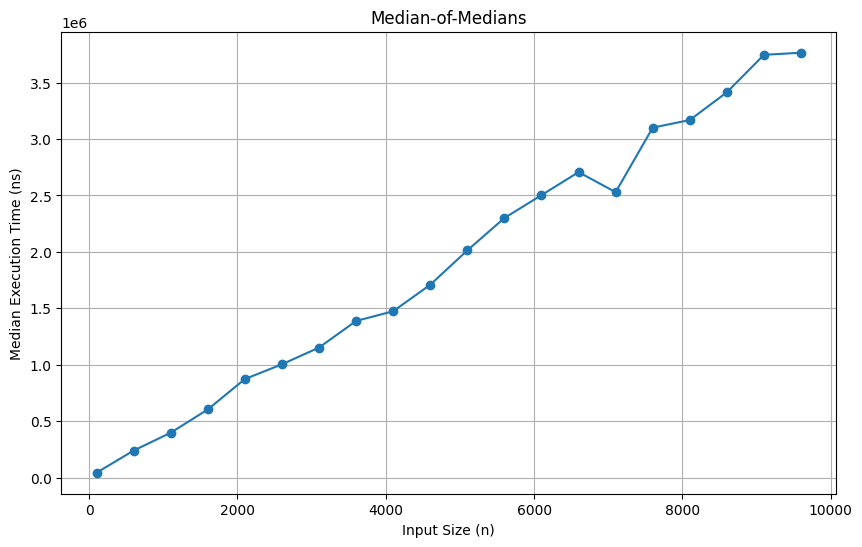

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Median-of-Medians")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()